In [2]:
import pandas as pd
import seaborn as sns

In [3]:
# MLR coefficients
MODEL_CONSTANT = 0.3761
MODEL_SPEED_COEF = 0.4139
MODEL_ACC_X_COEF = 1.1229

In [88]:
# speed coefficients
MODEL_CONSTANT = 3.7115
MODEL_SPEED_COEF = 0.9729
MODEL_ACC_X_COEF = 0

In [4]:
def remove_repeated_detection(array, recency_threshold):
    new_array = array.copy()
    iterations_since_poi = recency_threshold
    for i in range(len(new_array)):
        iterations_since_poi += 1
        if new_array.iloc[i] == True:
            if iterations_since_poi < recency_threshold:
                new_array.iloc[i] = False
            iterations_since_poi = 0
    return new_array

In [ ]:
tests = [(pd.read_csv(filename)) for filename in ["TestSegments\Baseline1.csv", "TestSegments\Baseline2.csv", "TestSegments\Bump1.csv", "TestSegments\DoubleBump1.csv", "TestSegments\SmallLargeBump1.csv","TestSegments\SmallLargeBump2.csv"]]

ROLLING_RANGE = 25
REPEATED_POI_PREVENTION_THRESHOLD = 40

for i in range(len(tests)):
    tests[i]['time'] = pd.to_datetime(tests[i]['time'])
    tests[i]['acc_z_norm'] = tests[i]['acc_z'] - 9.81 # difference from acceleration due to gravity
    tests[i]['acc_z_absn'] = abs(tests[i]['acc_z_norm'])
    tests[i]['acc_z_nroll'] = tests[i]['acc_z_norm'].rolling(ROLLING_RANGE).mean()
    tests[i]['acc_z_absnroll'] = tests[i]['acc_z_absn'].rolling(ROLLING_RANGE).mean()

    tests[i]['acc_x_norm'] = tests[i]['acc_x'] - tests[i]['acc_x'].mean() # 
    tests[i]['acc_x_absn'] = abs(tests[i]['acc_x_norm'])
    tests[i]['acc_x_nroll'] = tests[i]['acc_x_norm'].rolling(ROLLING_RANGE).mean()
    tests[i]['acc_x_absnroll'] = tests[i]['acc_x_absn'].rolling(ROLLING_RANGE).mean()

    tests[i]['acc_z_absnroll_pred'] = MODEL_CONSTANT + MODEL_SPEED_COEF * tests[i]['speed'] + MODEL_ACC_X_COEF * tests[i]['acc_x_absnroll']
    tests[i]['e'] = tests[i]['acc_z_absnroll'] - tests[i]['acc_z_absnroll_pred']

    tests[i]['POI'] = abs(tests[i]['e']) > 4.653
    tests[i]['POI'] = remove_repeated_detection(tests[i]['POI'], REPEATED_POI_PREVENTION_THRESHOLD)

In [7]:
CURRENT_TEST_NUMBER = 1

In [51]:
tests[CURRENT_TEST_NUMBER]['POI'].describe()

count      3830
unique        1
top       False
freq       3830
Name: POI, dtype: object

In [9]:
dot_sizes = {True: 100, False: 20}

<Axes: xlabel='time', ylabel='speed'>

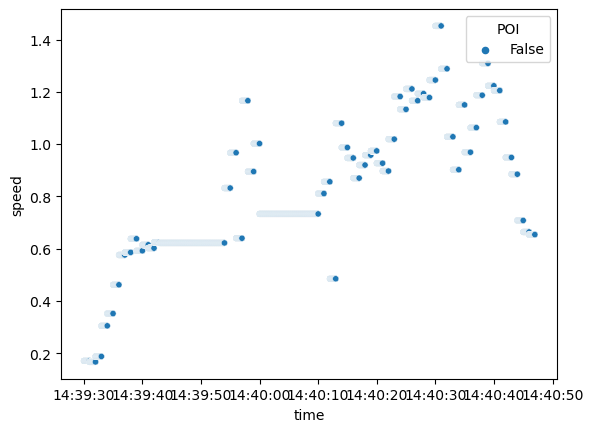

In [10]:
sns.scatterplot(data=tests[CURRENT_TEST_NUMBER], x='time', y='speed', hue='POI', size='POI', sizes=dot_sizes)

<Axes: xlabel='time', ylabel='acc_z_absnroll'>

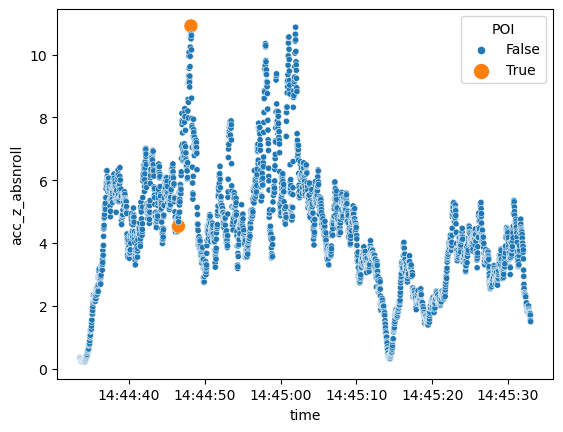

In [41]:
sns.scatterplot(data=tests[CURRENT_TEST_NUMBER], x='time', y="acc_z_absnroll", hue='POI', size='POI', sizes=dot_sizes)

<Axes: xlabel='acc_z_absnroll_pred', ylabel='acc_z_absnroll'>

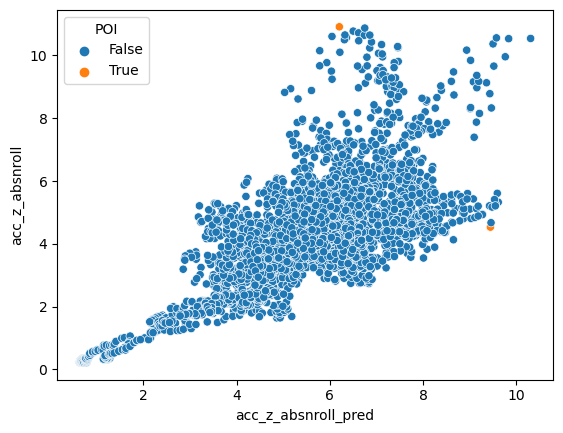

In [42]:
sns.scatterplot(data=tests[CURRENT_TEST_NUMBER], x='acc_z_absnroll_pred', y="acc_z_absnroll", hue='POI')

<Axes: xlabel='time', ylabel='e'>

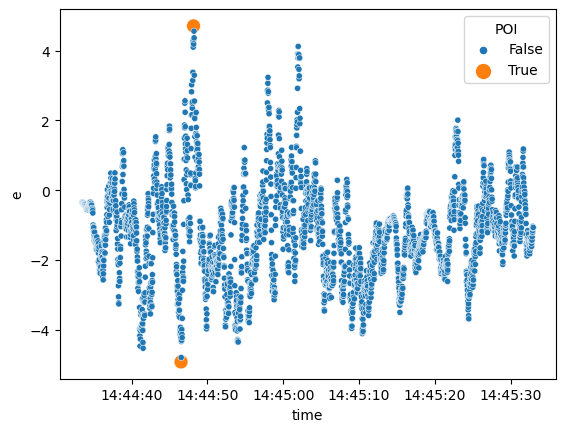

In [43]:
sns.scatterplot(data=tests[CURRENT_TEST_NUMBER], x='time', y='e', hue='POI', sizes=dot_sizes, size='POI')